In [1]:
import os
os.chdir('../..')

In [2]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from loguru import logger
from utils.load_datasets import QM9Loader
from ase.io import write, read
import numpy as np

/Users/karlfindhansen/Desktop/DTU/Kandidat/Thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
qm9_loader = QM9Loader()
frames = qm9_loader.get_stress_test_data()

In [4]:
print(f"Loaded {len(frames)} total frames.")

first_frame = frames[0]

print(first_frame.get_positions())

print(first_frame.info['mol_id'])
print(first_frame.info['smiles'])

Loaded 200 total frames.
[[ 2.23479131 -1.23890526 -0.15114536]
 [ 1.26223544 -0.81651978 -0.08916716]
 [ 1.40974743  0.79468064  0.09235649]
 [ 0.06662947  1.38542971  0.09025475]
 [-1.16100661  0.72018647 -0.05868188]
 [-1.20831189 -0.79789938  0.02779222]
 [ 0.01680941 -1.46143518 -0.03295169]
 [ 2.126203    1.32916262  0.16499038]
 [-0.02946341  2.49607651  0.27047955]
 [-2.2232373   0.96544116  0.21297781]
 [-2.07552691 -1.37314021 -0.12346329]
 [ 0.0199374  -2.48754814 -0.08901461]]
qm9_894
O=c1cccc[nH]1


In [5]:
ref_pos = frames[0].get_positions()
pert_pos = frames[1].get_positions()

distances = np.linalg.norm(pert_pos - ref_pos, axis=1)

print(f"Analysis for {frames[0].info['mol_id']}:")
print(f"Max displacement: {distances.max():.4f} Å")
print(f"Min displacement: {distances.min():.4f} Å")
print(f"Average displacement: {distances.mean():.4f} Å (Target was ~0.2)")

Analysis for qm9_894:
Max displacement: 0.3908 Å
Min displacement: 0.0630 Å
Average displacement: 0.1731 Å (Target was ~0.2)


In [6]:
bond_lengths = []
for i in range(20):
    dist = frames[i].get_distance(0, 1)
    bond_lengths.append(dist)

print(f"Original Bond Length (approx): {bond_lengths[0]:.4f} Å")
print(f"Standard Deviation of bond length: {np.std(bond_lengths):.4f} Å")

Original Bond Length (approx): 1.0621 Å
Standard Deviation of bond length: 0.1667 Å


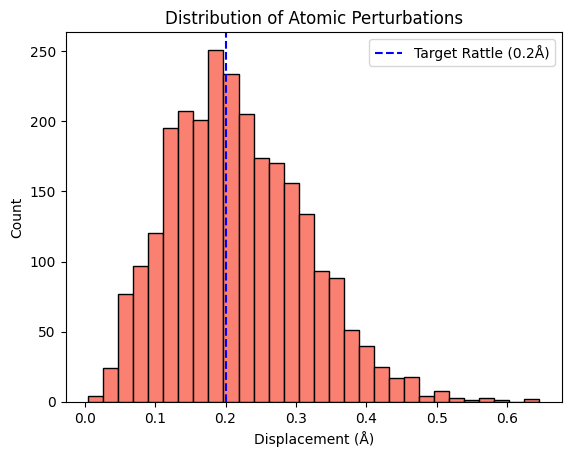

In [7]:
all_displacements = []

for m in range(0, 200, 20):
    ref_pos = frames[m].get_positions()
    for p in range(1, 20):
        pert_pos = frames[m + p].get_positions()
        diff = np.linalg.norm(pert_pos - ref_pos, axis=1)
        all_displacements.extend(diff)

plt.hist(all_displacements, bins=30, color='salmon', edgecolor='black')
plt.axvline(0.2, color='blue', linestyle='--', label='Target Rattle (0.2Å)')
plt.title("Distribution of Atomic Perturbations")
plt.xlabel("Displacement (Å)")
plt.ylabel("Count")
plt.legend()
plt.show()